In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from calculations import fret_calculations, processing_cleanup
import matplotlib as mpl
from IPython.display import display
import scipy.stats as stats
from calculations.significance import set_pvalue
import matplotlib.patches as mpatches
from dataframe_handling import plotting_df_functions

In [2]:
def osmotic_delta_efret(df, group_values = ['construct', 'date', 'experimentcondition', 'replicate']):
    df = df.copy()
    
    
    grouped = df.groupby(['construct', 'date', 'experimentcondition', 'replicate'], as_index=False)
    
    new_df =pd.DataFrame()
    for key, group in grouped:
        
        
        df1 = group[group['timepoint'] == 0].sort_values(by='label').reset_index(drop=True)
        df2 = group[group['timepoint'] == 1].sort_values(by='label').reset_index(drop=True)
        
        if len(df1) == 0 or len(df2) == 0:
            print('Empty dataframe')
            continue
            
        # Optional safety check
        if not all(df1['label'].values == df2['label'].values):
            raise ValueError(f"Label mismatch between before/after for key {key1}")
        
        df2 = df2.copy()
        df1['delta_Efret'] = df1.loc[:, 'Efret'].values - df1.loc[:, 'Efret'].values
        df2['delta_Efret'] = df2.loc[:, 'Efret'].values - df1.loc[:, 'Efret'].values
        new_df = pd.concat([new_df, df1, df2], ignore_index =True) 
        
    new_df = new_df.reset_index(drop=True)
    return new_df
        

In [3]:
raw_data_path = r'W:\OneDrive\Virus\Paper1\Raw_data_CSVs\Other'
df = pd.read_csv(raw_data_path + '\\osmotic_df.csv')
df = df.iloc[:, 1:]

display(df)

,label,area,donor_intensity_mean,donor_intensity_min,donor_intensity_max,donor_intensity_std,acceptor_intensity_mean,acceptor_intensity_min,acceptor_intensity_max,acceptor_intensity_std,...,experiment,experimentcondition,experimentparameter,replicate,passages,exposurecam1,exposurecam2,cyanled,blueled,greenled
0,1,8471.0,4073.572510,942.000000,8460.000000,1676.013184,4817.191895,1007.038086,10077.194336,2057.397217,...,Osmotic,Osmotic,750,1,18,25,25,12U5,12U5,6U5
1,2,4031.0,2609.682617,1374.000000,4586.000000,737.663757,3129.041992,1520.009644,5393.633789,899.280457,...,Osmotic,Osmotic,750,1,18,25,25,12U5,12U5,6U5
2,3,6907.0,2425.898438,1186.000000,5101.000000,731.983765,3000.018311,981.330688,5901.328125,906.207520,...,Osmotic,Osmotic,750,1,18,25,25,12U5,12U5,6U5
3,4,2374.0,5712.759277,1998.000000,10557.000000,1685.490479,7008.212402,2641.855713,12892.326172,1994.331177,...,Osmotic,Osmotic,750,1,18,25,25,12U5,12U5,6U5
4,5,11390.0,15422.658203,3773.000000,31243.000000,6718.361328,17743.447266,1315.328613,37055.296875,8572.196289,...,Osmotic,Osmotic,750,1,18,25,25,12U5,12U5,6U5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47589,9,5202.0,282.269104,202.542740,422.900635,25.646067,901.869934,513.356873,1327.414307,129.113739,...,Osmotic,Osmotic,750,3,32,25,25,12U5,12U5,6U5
47590,10,8985.0,294.284515,162.078918,526.362976,34.006702,1425.366699,547.405334,2928.533447,502.391022,...,Osmotic,Osmotic,750,3,32,25,25,12U5,12U5,6U5
47591,11,12468.0,298.724701,204.380569,496.076630,34.335445,1761.318848,502.006714,4643.606445,911.332825,...,Osmotic,Osmotic,750,3,32,25,25,12U5,12U5,6U5
47592,12,19641.0,277.745056,191.058304,499.969299,29.771160,1370.094727,517.749329,4678.107422,788.224609,...,Osmotic,Osmotic,750,3,32,25,25,12U5,12U5,6U5


In [4]:
comb_df = df

tmp_df = processing_cleanup.pixels_to_micron(comb_df)
tmp_df = fret_calculations.acceptor_correction(tmp_df)
tmp_df = fret_calculations.calculate_efret(tmp_df)
tmp_df = osmotic_delta_efret(tmp_df)
tmp_df = processing_cleanup.area_cutoffs(tmp_df)
tmp_df = processing_cleanup.remove_maximums(tmp_df, 'directAcceptor')
tmp_df = processing_cleanup.remove_minimums(tmp_df, 'directAcceptor', value_cutoff=200)
tmp_df = processing_cleanup.directacceptor_mean_cutoffs(tmp_df, lower_cutoff=800)
tmp_df = processing_cleanup.donor_mean_cutoffs(tmp_df)
print(tmp_df)

       label  area_pixels  donor_intensity_mean  donor_intensity_min  \
0          1       8035.0           3987.397217          1182.000000   
1          1       4108.0            611.305481           320.000000   
2          2       4070.0            714.668335           300.000000   
3          2       5982.0           2213.001953           783.000000   
4          3       8146.0           1397.080811           385.000000   
...      ...          ...                   ...                  ...   
36593     13      12867.0           6679.552246           364.408447   
36649     10       6787.0           3841.209961           607.137451   
36651     11       6103.0           3531.228027           755.679932   
36652     12       8942.0           4822.838867           292.687012   
36654     13      12867.0           6847.515137           350.870972   

       donor_intensity_max  donor_intensity_std  acceptor_intensity_mean  \
0              6189.000000           954.414978            

In [5]:
def before_after_significance(df, construct):
    con_df = df.loc[(df['construct']) == construct]

    grouped_values = con_df.groupby(['timepoint','date', 'well'])['Efret'].median()
    compare_before = grouped_values[0]
    compare_after = grouped_values[1]

    _, p_val = stats.ttest_ind(compare_before, compare_after, equal_var=False)
    return {construct: p_val}

def update_star_values(dic):
    for k, v in dic.items():
        if isinstance(v, str):
            dic[k] = v.replace("*", "+")
    return dic

def get_pvalue_sig(dic):
    sig_dic = {key: set_pvalue(item) for key, item in dic.items()}
    return update_star_values(sig_dic)


def set_before_after_signficance(df):
    uni_construct = df['construct'].unique()
    
    tmp_dic = {}
    for x in uni_construct:
        tmp_dic.update(before_after_significance(df, x))

    return get_pvalue_sig(tmp_dic)


BA_comparison = set_before_after_signficance(tmp_df)
BA_comparison

{'1': '++++',
 '10': '++++',
 '11': '++++',
 '12': '++++',
 '2': '+',
 '3': '+',
 '4': 'ns',
 '5': '+++',
 '6': '++++',
 '7': '++++',
 '8': '++++',
 '9': '++++',
 'GS32': '++++',
 'SED1': '++',
 'mNG': 'ns'}

In [10]:
tmp_df.groupby(['construct', 'timepoint'])['Efret'].count()

construct  timepoint
1          0            1106
           1            1143
10         0             753
           1             682
11         0             778
           1             727
12         0            1345
           1            1162
2          0             600
           1             611
3          0            1003
           1             858
4          0             667
           1             587
5          0            1322
           1            1202
6          0             697
           1             594
7          0             752
           1             678
8          0             917
           1             802
9          0             768
           1             733
GS32       0             739
           1             662
SED1       0             969
           1             839
mNG        0               4
           1               2
Name: Efret, dtype: int64

<Axes: xlabel='construct', ylabel='Efret'>

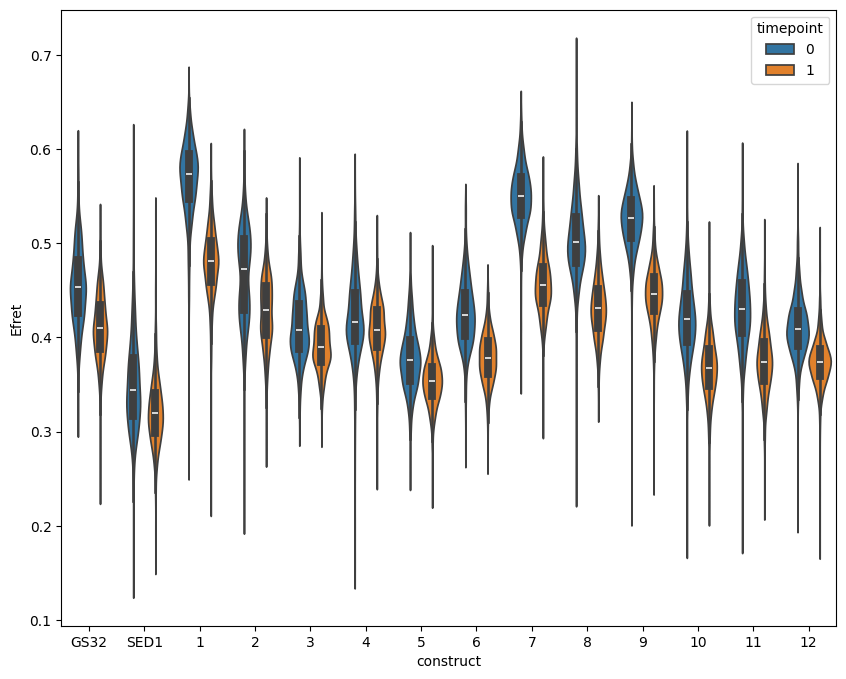

In [8]:
recom_df = tmp_df
recom_df['experimentparameter'] = recom_df['experimentparameter'].astype(str)
#recom_df = recom_df.loc[(recom_df['construct']=='1') | (recom_df['construct']=='4') | (recom_df['construct']=='7') | (recom_df['construct']=='8') | (recom_df['construct']=='9')]

constructs = ['GS32', 'SED1', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
experiment_condition = ['Osmotic']
experiment_parameter = ['750']

my_sort_dict = {
            'construct' : constructs,
            'experimentcondition': experiment_condition,
            'experimentparameter': experiment_parameter, 
               }


#GS32 = recom_df.loc[(recom_df['construct']== 'GS32')]
recom_df = recom_df.loc[(recom_df['construct']!= 'mTQ2')&(recom_df['construct']!= 'mNG')]
recom_df = processing_cleanup.sort_values(recom_df, my_sort_dict)
recom_df = recom_df.reset_index(drop=True)
if 'Unnamed: 0.1' in recom_df.columns:
    recom_df = recom_df.drop(columns=['Unnamed: 0.1'])

fig, ax = plt.subplots(figsize = (10, 8))
#sns_df = recom_df.loc[recom_df['timepoint']== 1]
sns.violinplot(data=recom_df, x= 'construct', y='Efret', hue='timepoint')


In [21]:
print(len(recom_df))
groupby_values = ['construct', 'experiment', 'experimentcondition', 'experimentparameter',  'timepoint']
filtered_df = processing_cleanup.remove_outliers(recom_df, groupby_values, 'Efret')
print(len(filtered_df))

23696
22762


In [13]:
groupby_values_per_repeat = ['construct', 'date', 'timepoint', 'well',]
groupby_values_per_experiment = ['construct', 'timepoint']

total_stats_df = processing_cleanup.get_stats(filtered_df, groupby_values_per_repeat, stat_column='delta_Efret')
experiment_stats = processing_cleanup.get_stats(filtered_df, groupby_values_per_experiment, stat_column='delta_Efret')
#display(total_stats_df)


groupby_values_experiment = ['construct', 'timepoint']
holder_df = processing_cleanup.get_population_significance(total_stats_df, groupby_values_experiment, comparison_value = 'GS32', comparison_column='construct', sign_column='delta_Efret_median')
ttest_df = holder_df.dropna()

new_values =  ['construct','timepoint']

population_count_df = processing_cleanup.get_stats(total_stats_df, new_values, ['count'], stat_column='delta_Efret_median')
median_std_df = processing_cleanup.get_stats(total_stats_df, new_values, ['std'], stat_column='delta_Efret_median')
list_efret_df = processing_cleanup.get_stats(total_stats_df, new_values, ['list'], stat_column='delta_Efret_median')
population_count_df = population_count_df.drop(columns=new_values)
median_std_df = median_std_df.drop(columns = new_values)
list_efret_df = list_efret_df.drop(columns = new_values)
population_count_df = population_count_df.rename(columns={'delta_Efret_median_count': 'well_count_per_timepoint'})
median_std_df = median_std_df.rename(columns={'delta_Efret_median_std': 'std_median_per_timepoint'})
list_efret_df = list_efret_df.rename(columns={'delta_Efret_median_std': 'list_median_per_timepoint'})

merged_data = pd.concat([experiment_stats, population_count_df, median_std_df, list_efret_df], axis=1)
#merged_data.to_csv(r'E:\Patrick\Test_data.csv')

merged_data = merged_data.merge(ttest_df, on=['construct', 'timepoint',])

merged_delta = merged_data.copy()


merged_delta = processing_cleanup.remove_controls(merged_delta)
merged_delta = processing_cleanup.drop_counts(merged_delta, count_column='delta_Efret_count', count=40)



total_df = total_stats_df.copy()

total_df = processing_cleanup.remove_controls(total_df)

'''
merged_delta['delta_median_wells'] = total_df.groupby(['construct','timepoint'], observed=False, as_index=False)['delta_Efret_median'].apply(np.array)
consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]
consolidated_values = consolidated_values.dropna().reset_index(drop=True).rename(columns={'delta_Efret_median': 'delta_median_wells'})

#merged_delta = merged_delta.merge(consolidated_values, on=['construct', 'experiment', 'experimentparameter', 'timepoint'], how='left')

merged_delta['delta_Efret_population'] = total_df.groupby(['construct','timepoint'], observed=False, as_index=False)['delta_Efret_list'].apply(np.array)
print(len(merged_delta['delta_Efret_population'].iloc[0]), merged_delta['delta_Efret_population'].iloc[1])
#consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]
#consolidated_values = consolidated_values.dropna().reset_index(drop=True).rename(columns={'delta_Efret_median': 'delta_Efret_population'})

#merged_delta = merged_delta.merge(consolidated_values, on=['construct', 'timepoint'], how='left')
'''

consolidated_values = total_df.groupby(['construct', 'timepoint'], observed=False, as_index=False)['delta_Efret_median'].apply(np.array)
consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]


merged_delta = merged_delta.merge(consolidated_values, on=['construct',  'timepoint'], how='left')

consolidated_values = total_df.groupby(['construct', 'timepoint'], observed=False, as_index=False)['delta_Efret_list'].apply(np.array)
consolidated_values = consolidated_values.loc[(consolidated_values['construct']!= 'mTQ2') & (consolidated_values['construct']!= 'mNG')]
consolidated_values = consolidated_values.dropna().reset_index(drop=True).rename(columns={'delta_Efret_median': 'delta_Efret_population'})

merged_delta = merged_delta.merge(consolidated_values, on=['construct', 'timepoint'], how='left')


merged_df = plotting_df_functions.create_list_columns(total_df, merged_delta, group_values=['construct', 'timepoint'])
merged_df = plotting_df_functions.create_list_columns(total_df, merged_delta, type = 'list', group_values=['construct', 'timepoint'])

tmpr_df = merged_delta.copy()

construct_order = {c: i + 1 for i, c in enumerate(constructs)}

tmpr_df = tmpr_df.loc[(tmpr_df['timepoint']!=0)]
tmpr_df['base_position'] = tmpr_df['construct'].map(construct_order)

# Step 2: For each unique (construct, experimentparameter) pair, compute a subposition offset.
# This mapping is computed once, so it is consistent across all timepoints.
mapping = {}
for construct, order in construct_order.items():
    
    # Get unique experimentparameters for this construct, preserving order of appearance
    unique_params = pd.unique(tmpr_df.loc[tmpr_df['construct'] == construct, 'timepoint'])
    n = len(unique_params)
    # Compute offsets evenly in [-0.5, 0.5] (you can adjust the range as needed)
    offsets = (np.arange(n) - (n-1) / 2) / 4
    for exp, offset in zip(unique_params, offsets):
        mapping[(construct, exp)] = offset

# Step 3: Apply the mapping to assign a subposition to every row.
tmpr_df['subposition_offset'] = tmpr_df.apply(lambda row: mapping[(row['construct'], row['timepoint'])], axis=1)

tmpr_df['base_position'] = tmpr_df['base_position'].astype(int)
# Step 4: The final plot position for a row is the sum of its base position and subposition offset.
tmpr_df['plot_position'] = tmpr_df['base_position'] + tmpr_df['subposition_offset']
tmpr_df = tmpr_df.loc[(tmpr_df['timepoint']!=0)]


constructs = ['GS32', 'SED1', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']

my_sort_dict = {
            'construct' : constructs,
               }


tmpr_df = processing_cleanup.sort_values(tmpr_df, my_sort_dict)
display(tmpr_df.columns)

Index(['construct', 'timepoint', 'delta_Efret_mean', 'delta_Efret_median_x',
       'delta_Efret_min', 'delta_Efret_max', 'delta_Efret_std',
       'delta_Efret_count', 'delta_Efret_var', 'delta_Efret_list_x',
       'well_count_per_timepoint', 'std_median_per_timepoint',
       'delta_Efret_median_list', 'ttest', 'pvalue', 'star_value',
       'delta_Efret_median_y', 'delta_Efret_list_y', 'base_position',
       'subposition_offset', 'plot_position'],
      dtype='object')

In [22]:
filtered_df.to_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\combined_experiments\osmotic_tiles.pkl')

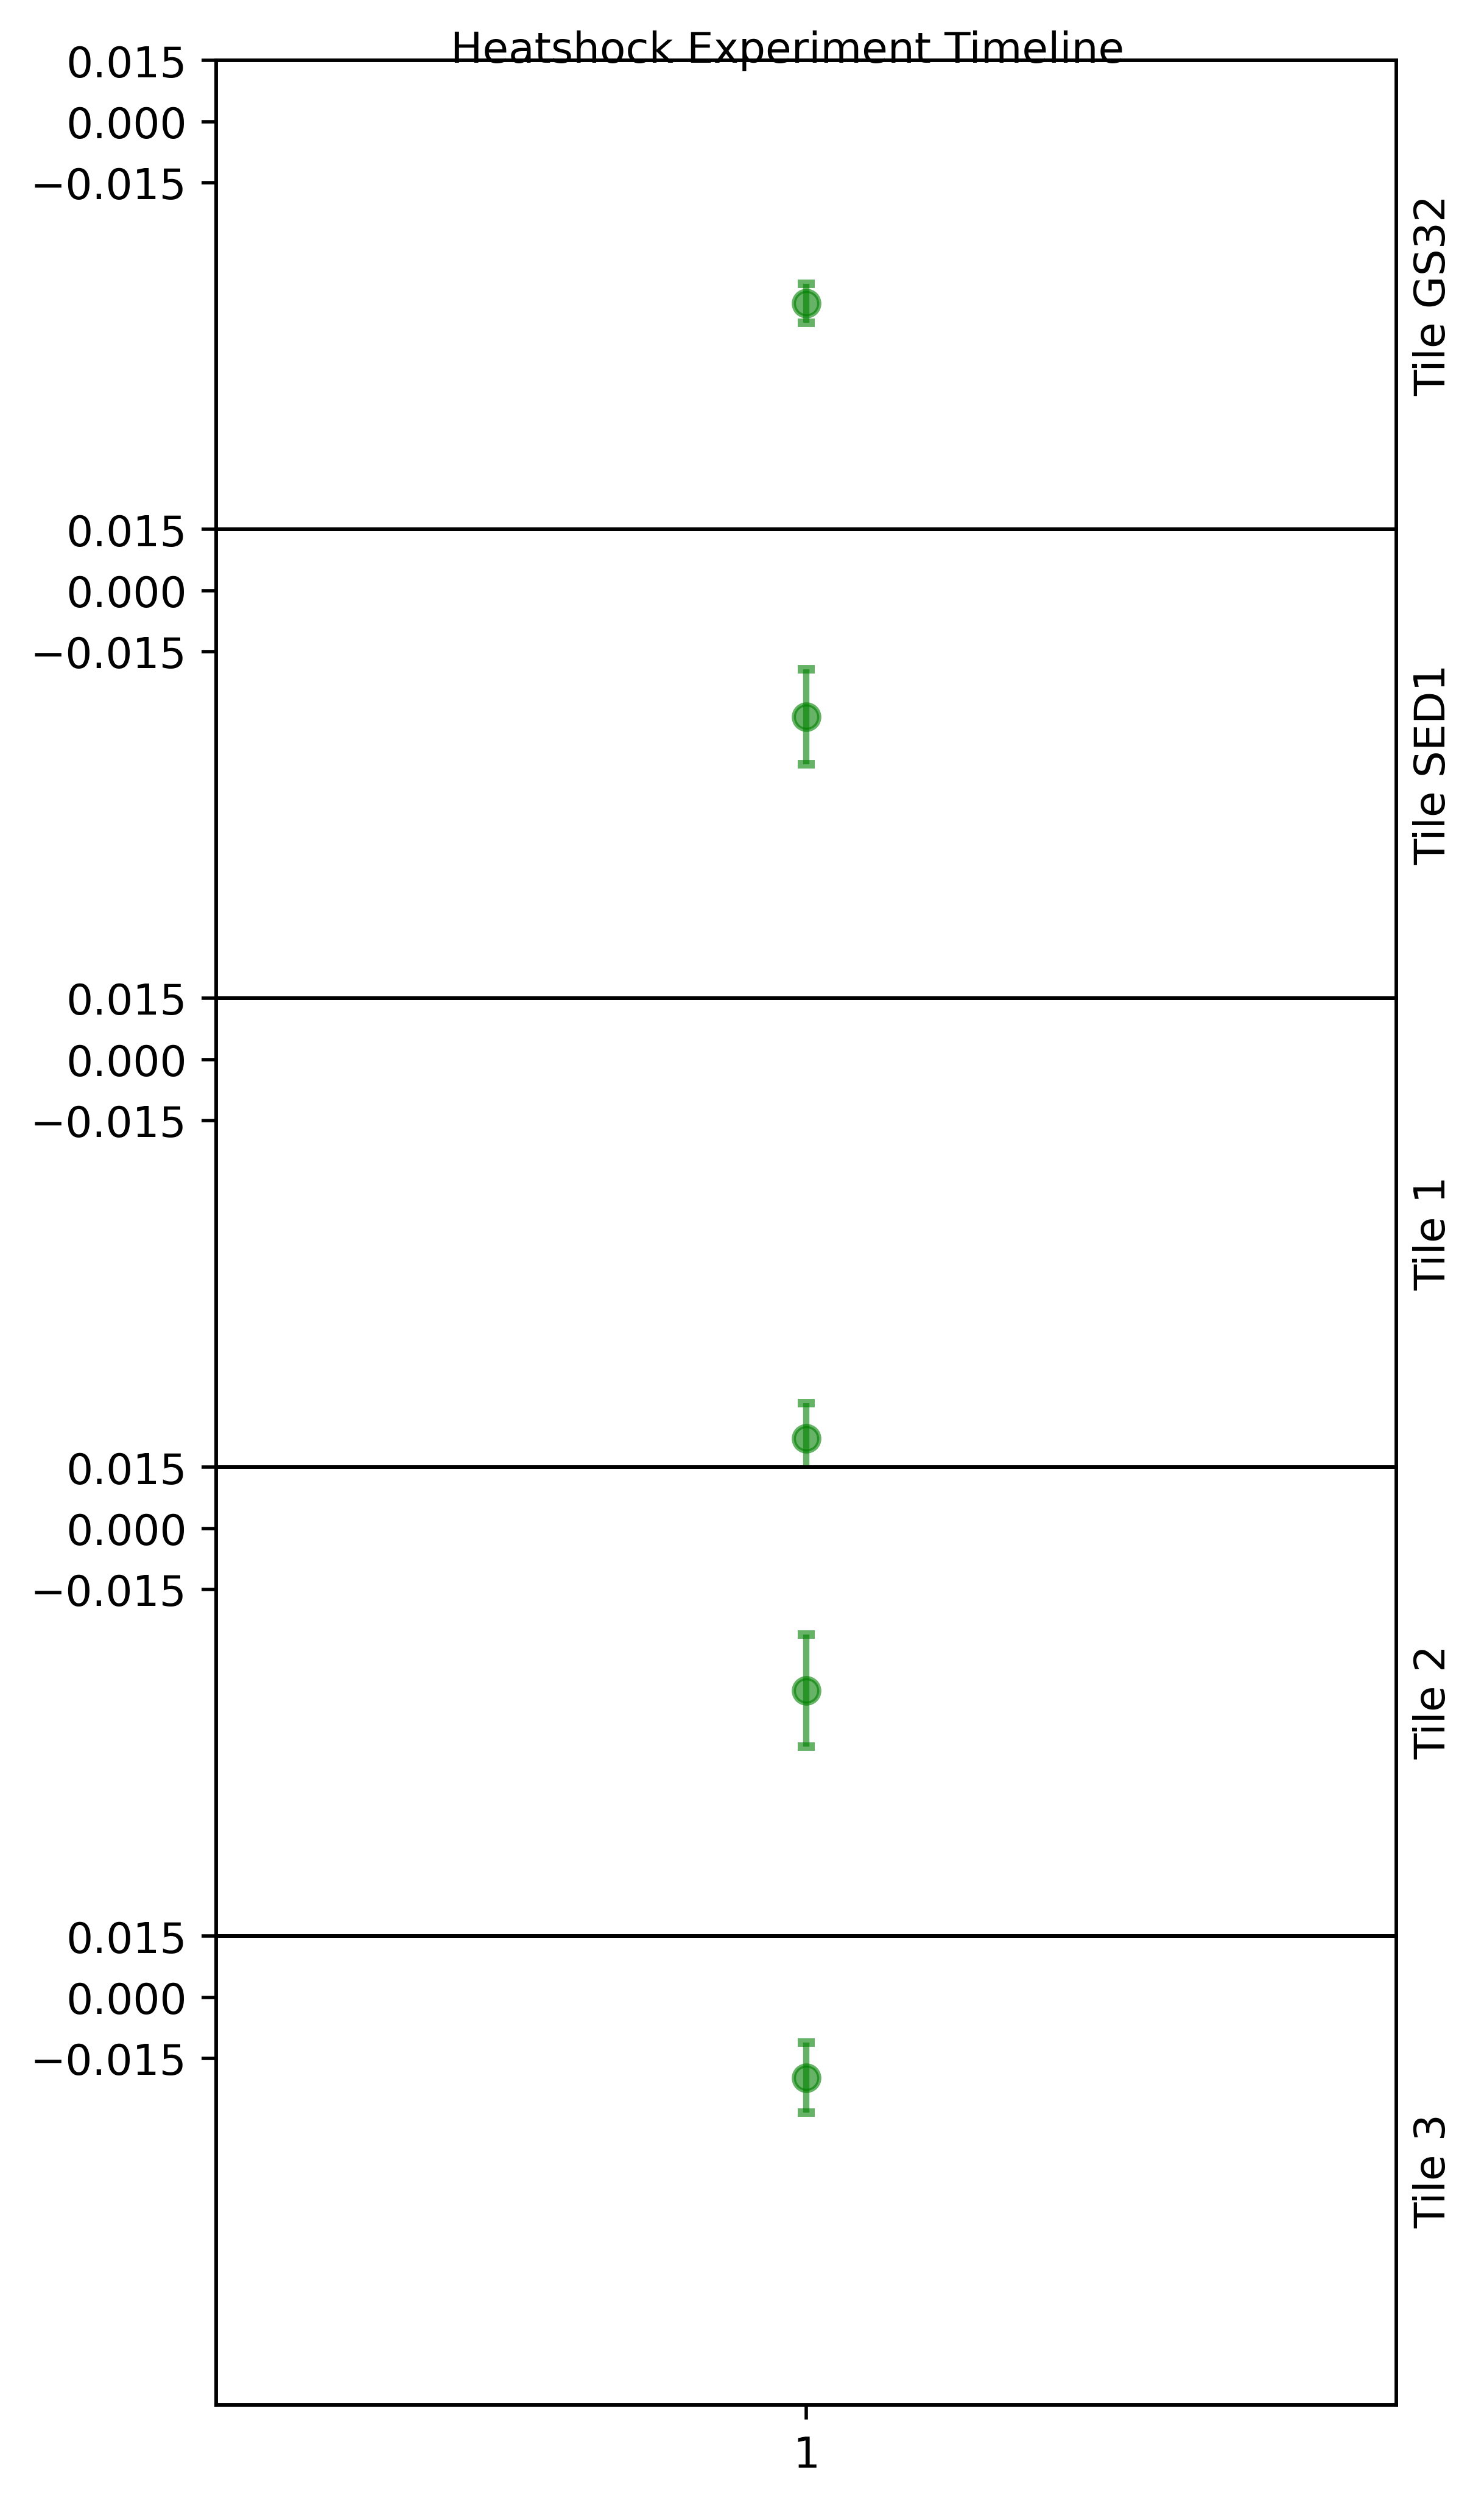

In [9]:
generator = tmpr_df.groupby('construct', observed=True)
mpl.rcParams['figure.dpi'] = 500
fig_len = 5
fig, ax =plt.subplots(fig_len,  1, figsize=(5,10)) 
for index, container in enumerate(generator):
    construct = container[0]
    
    if index < fig_len:
        container_df = container[1]
        
        
        indexer = 0
        colors = ['green', 'k', 'dodgerblue', 'firebrick']
        for parameter in container_df.experimentparameter.unique():
            
            current_parameter = container_df.loc[container_df['experimentparameter']== parameter]
            #current_parameter['timepoint'] = (current_parameter['timepoint'] * 0.5) -1
            
            ax[index].scatter(x=current_parameter['timepoint'], y=current_parameter['delta_Efret_median'], alpha=0.6, c=colors[indexer], zorder=3)
            ax[index].errorbar(current_parameter['timepoint'], current_parameter['delta_Efret_median'], yerr = current_parameter['std_median_per_timepoint'], c=colors[indexer],
                                                    capsize=2, capthick=2, alpha=0.6)
            indexer += 1
        ax[index].set_ylim(-0.1, 0.01)
        ax[index].set_yticks([-0.015, 0, 0.015])
        ax[index].set_xticks([])
        #ax[index].axvline(x=0.0, c='k', linestyle='--')
        #ax[index].axhline(y=0.0, c='k', linestyle='--')
        ax2 = ax[index].twinx()
        ax2.set_yticks([])
        ax2.set_ylabel(ylabel = 'Tile ' + str(construct))

tick_array = np.array(current_parameter['timepoint'])
ax[-1].set_xticks(tick_array)
fig.suptitle('Heatshock Experiment Timeline', fontsize=10, x=0.5, y=0.89)
plt.subplots_adjust(hspace=0)
#plt.savefig(r'D:\OneDrive\Virus\Paper1\Paper1_figures\heatshock_42-45_timeline_5contructs.svg', format='svg', bbox_inches='tight')

In [36]:
print(tmpr_df['delta_Efret_list'].iloc[0])

[-0.04263858668318288, -0.04030061322098222, -0.06147230629471018, -0.0709838847251465, -0.056670766326829214, -0.04625836493787561, -0.04223938427470769, -0.049667534831013715, -0.053654738698665494, -0.07209775861457224, -0.04355053050444474, -0.040871254702839144, -0.052333803492985276, -0.03227707758795584, -0.05078085384543979, -0.050287783934459984, -0.03513282592862471, -0.05195146583955618, -0.043618408872843906, -0.05117356931446676, -0.04199527950759163, -0.0483824135789751, -0.044744028527478386, -0.0422724746363502, -0.03669368565934922, -0.048405424769512706, -0.04465116478063236, -0.03842571258873895, -0.04528907993980846, -0.04996780311993421, -0.0541448143279642, -0.04743873586235692, -0.0534323649056232, -0.050191585718553866, -0.059805009157358924, -0.04499692407445455, -0.028210841960816302, -0.04507268442133494, -0.04334755705333909, -0.04583620223472529, -0.05210514948939865, -0.04905465895883576, -0.04409273402748942, -0.047913270744836034, -0.043091835165579684, 

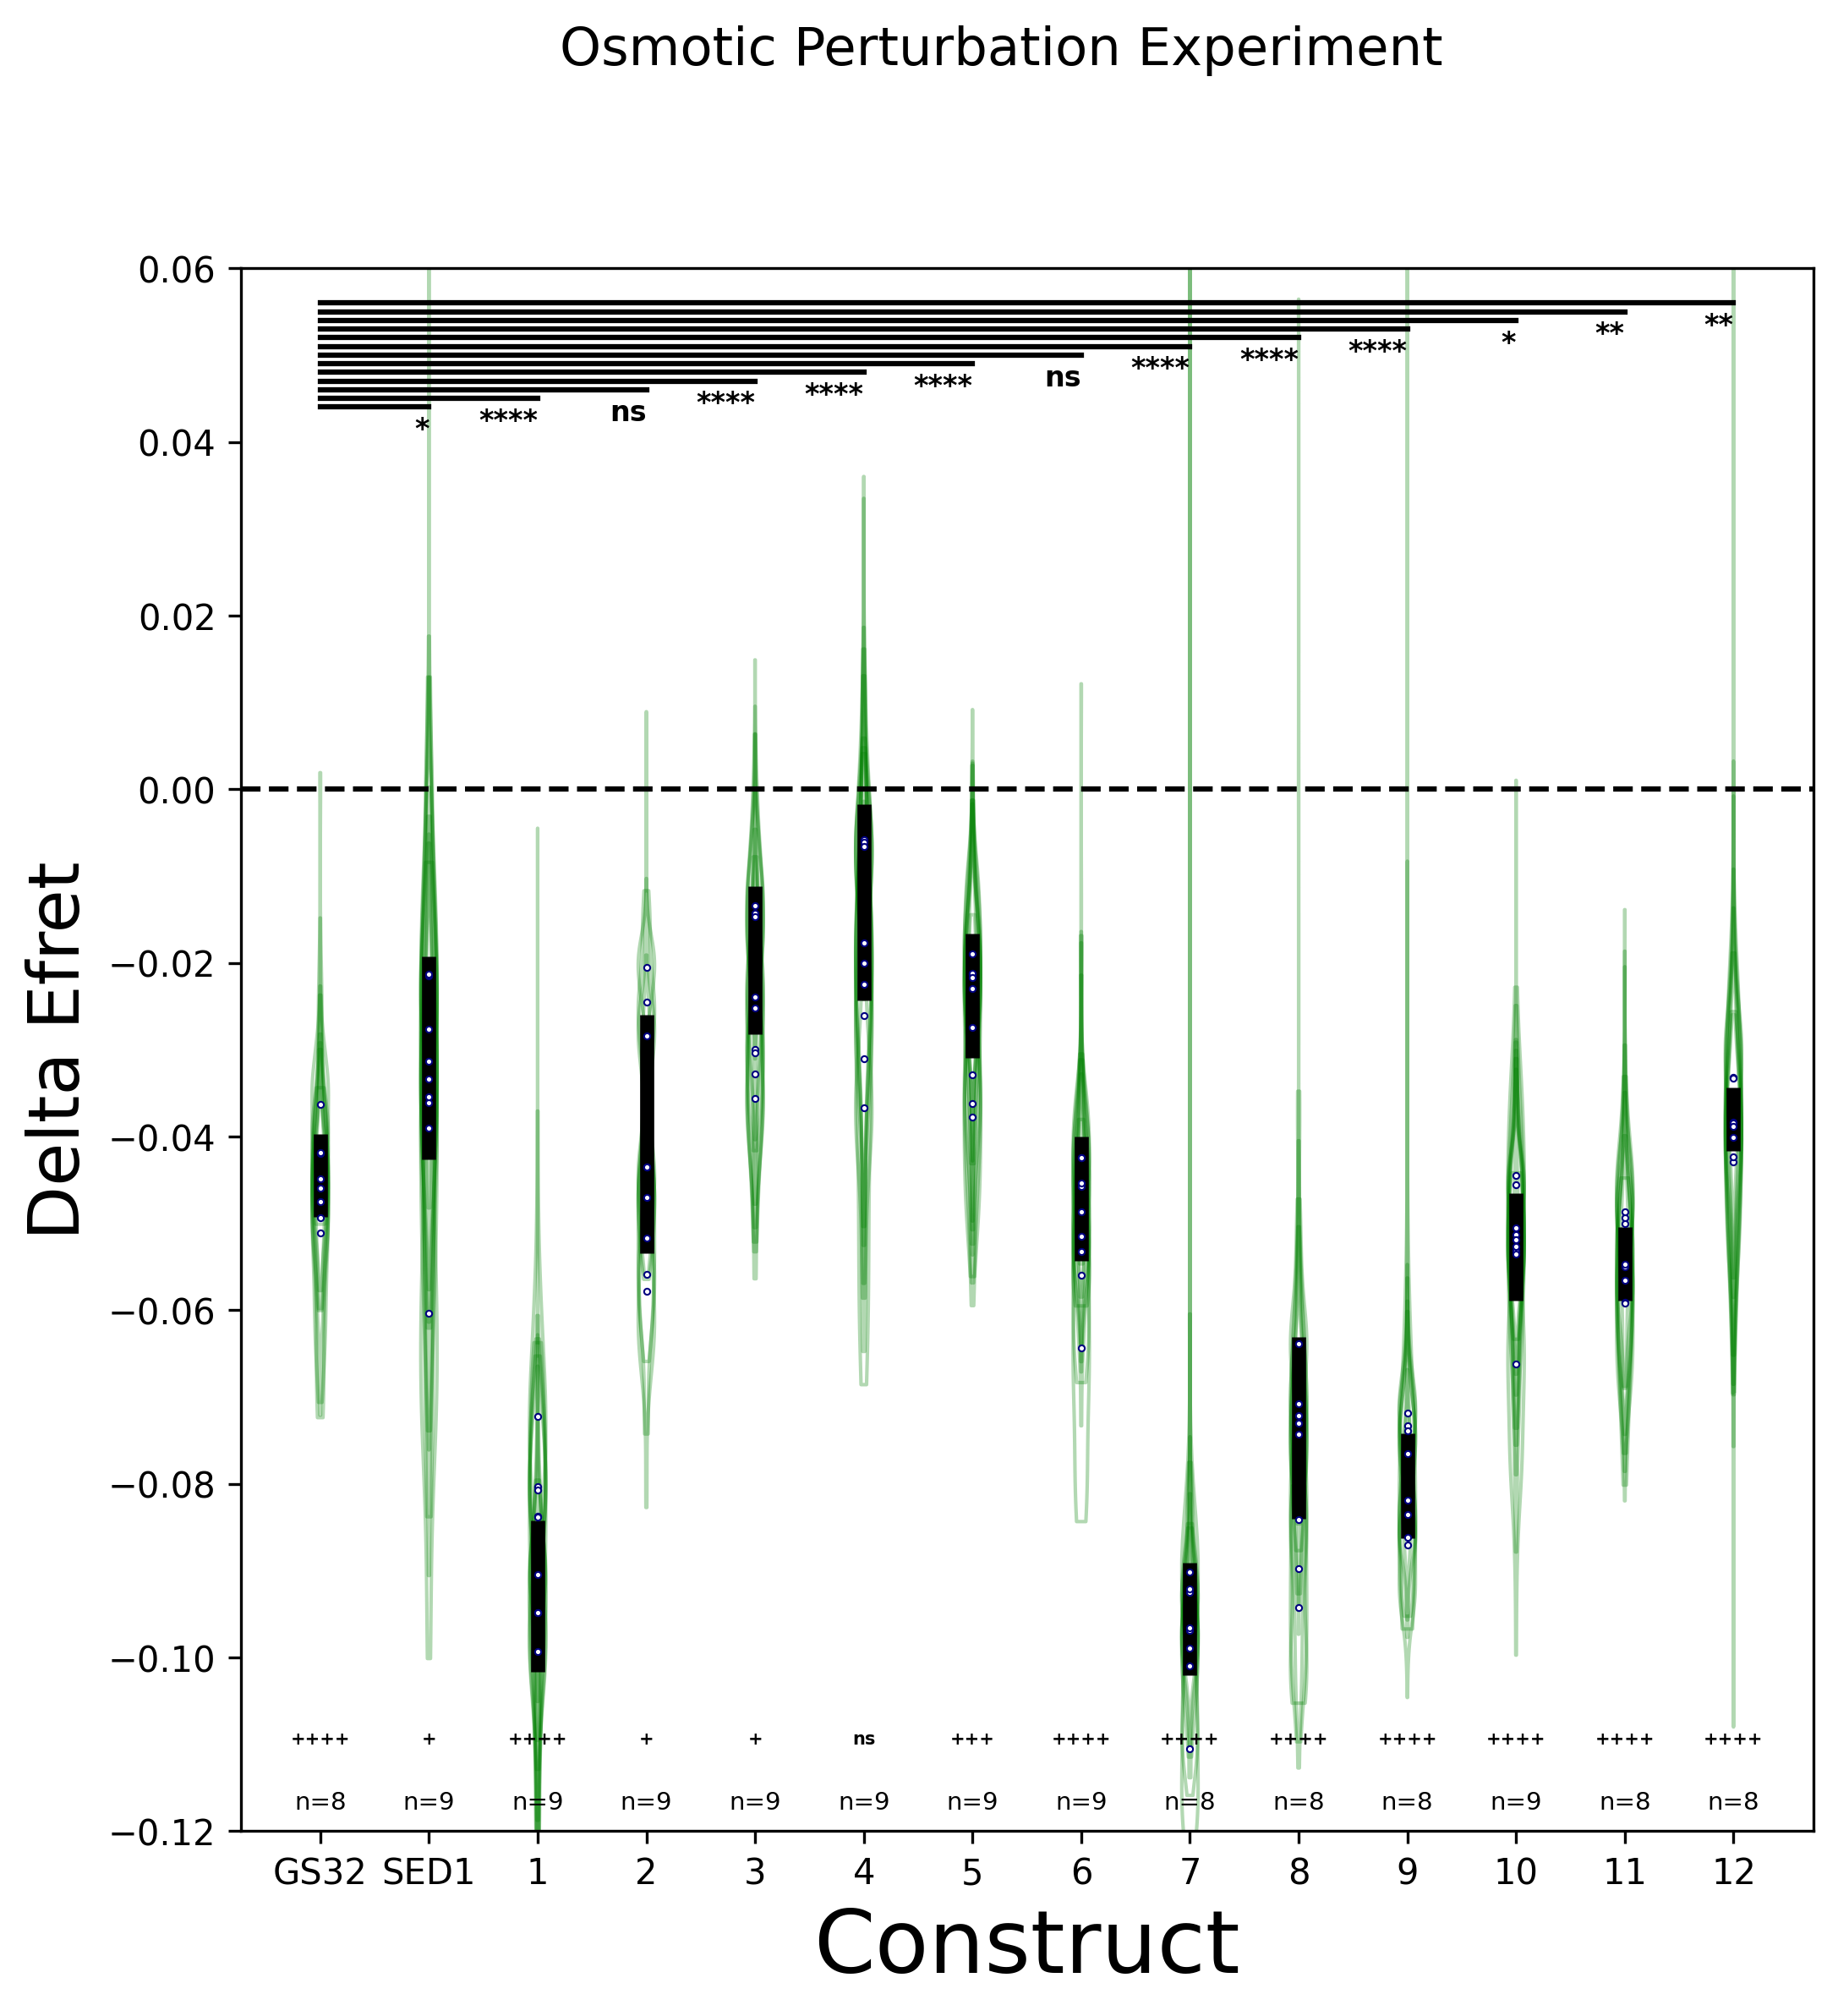

In [16]:
replaced_data = tmpr_df
violin_dataframe_path =r'D:/OneDrive/Virus/Paper1/processed_csvs/heatshock_42-45_violin_csv.csv'
save_csv = False
save_plot = False
if save_csv:
    replaced_data.to_csv(violin_dataframe_path)
#reduced_df = replaced_data.loc[(replaced_data['timepoint']==4) | (replaced_data['timepoint']==6) | (replaced_data['timepoint']==8)]
reduced_df = replaced_data
mpl.rcParams['figure.dpi'] = 300
colors = ['green', 'k', 'dodgerblue', 'firebrick']

construct = len(reduced_df.construct.unique())
timepoints = reduced_df.timepoint.nunique()

ylim =[ymin, ymax] = -0.12, 0.06

grouped_values = ['timepoint']

uni_construct = reduced_df.construct.unique()
#indexer length
row_len = timepoints

fig, ax = plt.subplots(row_len, 1, figsize=(8, 8))

new_tmp = reduced_df
#new_tmp['timepoint'] = new_tmp['timepoint'] * 0.5
median_violin_generator = new_tmp.groupby(grouped_values, observed=True, as_index=True)

for index, container in enumerate(median_violin_generator):
    tmp_df = container[1]
    row = index
    #plots Experiment median and std
    #ax.scatter(x= tmp_df['plot_position'], y=tmp_df['delta_Efret_median_x'], s=4, c='gray', zorder=3)
    ax.errorbar(x= tmp_df['plot_position'], y=tmp_df['delta_Efret_median_x'], yerr= tmp_df['std_median_per_timepoint'], linestyle='none', color='k',elinewidth=4, zorder=2)
    
    #offset star y values
    y=0
    #rest starting put when a new construct is iterated
    con_holder = None
    #plot star values
    for x in tmp_df['plot_position']:
        current_well_n = tmp_df.loc[tmp_df['plot_position']==x, 'well_count_per_timepoint'].iloc[0]
        ax.text(x, ymin+0.0025, f'n={current_well_n}', ha='center', fontsize=7)
        
        
        len_param = tmp_df.timepoint.nunique()
        current_construct = tmp_df.loc[tmp_df['plot_position']==x, 'construct'].iloc[0]
        sensitivity_sig = BA_comparison[current_construct]
        ax.text(x, -0.11, s=sensitivity_sig, fontsize=5, fontweight='bold', ha='center')
        
        if con_holder is None:
            con_holder = current_construct
        
        if current_construct == 'GS32':
            set_x = x
            continue

        x_coord = (set_x, x)
        y_pos = 0.044 + y*0.001
        star_val = tmp_df.loc[tmp_df['plot_position']==x, 'star_value']

        ax.text(x, y_pos-0.0035, s=star_val.iloc[0], fontsize=8, fontweight='bold', ha='right')
        ax.plot(x_coord, (y_pos, y_pos), c= 'k')

        
        y+=1
    ax.set_ylim(ylim)
    tmp_explode = tmp_df.explode('delta_Efret_median_list')
    ax.scatter(x=tmp_explode['plot_position'] , y=tmp_explode['delta_Efret_median_list'], s=3, c='white', edgecolor='navy', linewidth=0.5, zorder=4)
    
    tmp_explode = tmp_df.explode('delta_Efret_list_y')
    
    iterator = 0 
     
    
    
    for x in tmp_df['plot_position']:
        list_explode = tmp_explode.loc[tmp_explode['plot_position']== x]
        
        
        len_dataframe = len(list_explode)
        
        len_para = tmp_explode.timepoint.nunique()
            
        current_color = colors[iterator]
        
        for sub in range(len_dataframe):
            current_dataframe = list_explode.iloc[sub]
            final_explode = current_dataframe['delta_Efret_list_y']
            violins =ax.violinplot(final_explode, [x], widths=0.15, showextrema=False, showmedians=False, showmeans=False)
           

            
            for pc in violins['bodies']:
                pc.set_facecolor('None')
                pc.set_edgecolor(current_color)
                pc.set_aplha=0.3
    
        #iterator += 1
        
    ax.axhline(y=0, c='k', linestyle ='--')
    ax.set_xticks(np.arange(1, construct+1, 1))
    ax.set_xticklabels(uni_construct, fontsize='medium')

    ax.set_ylabel('Delta Efret', fontsize=20)
ax.set_xlabel('Construct', fontsize=25)

fig.suptitle('Osmotic Perturbation Experiment', fontsize=15, x=0.5, y=1)
if save_plot:
    plt.savefig(r'D:\OneDrive\Virus\Paper1\Paper1_figures\osmotic_delta_comparison_violin.svg', format='svg', bbox_inches='tight')
plt.show()


In [85]:
import statistics

statistics.median(tmp_df['delta_Efret_median_list'][5])

-0.08381946355276765

In [96]:
explode = test_df.explode('delta_Efret_population')

In [97]:
explode

0                                                   GS32
1                                                      1
2                                              -0.044941
3                                              -0.044527
4                                              -0.072391
                             ...                        
617    [-0.07978944706819857, -0.08094665091108905, -...
618    [-0.0812187104115808, -0.09446994193113739, -0...
619                                                    1
620                                                  0.0
621                                                  1.0
Name: 1, Length: 622, dtype: object

In [92]:
model_df = pd.read_csv(r'W:\OneDrive\Virus\Paper1\Raw_data_CSVs\Other\model_fret_length.csv')
model_df = model_df.iloc[:, 1:]

C:\Users\Owner\AppData\Local\Temp\ipykernel_4036\2104754129.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_df = length_change_df.groupby(['construct', 'timepoint'], as_index=False)['Efret'].median().dropna()


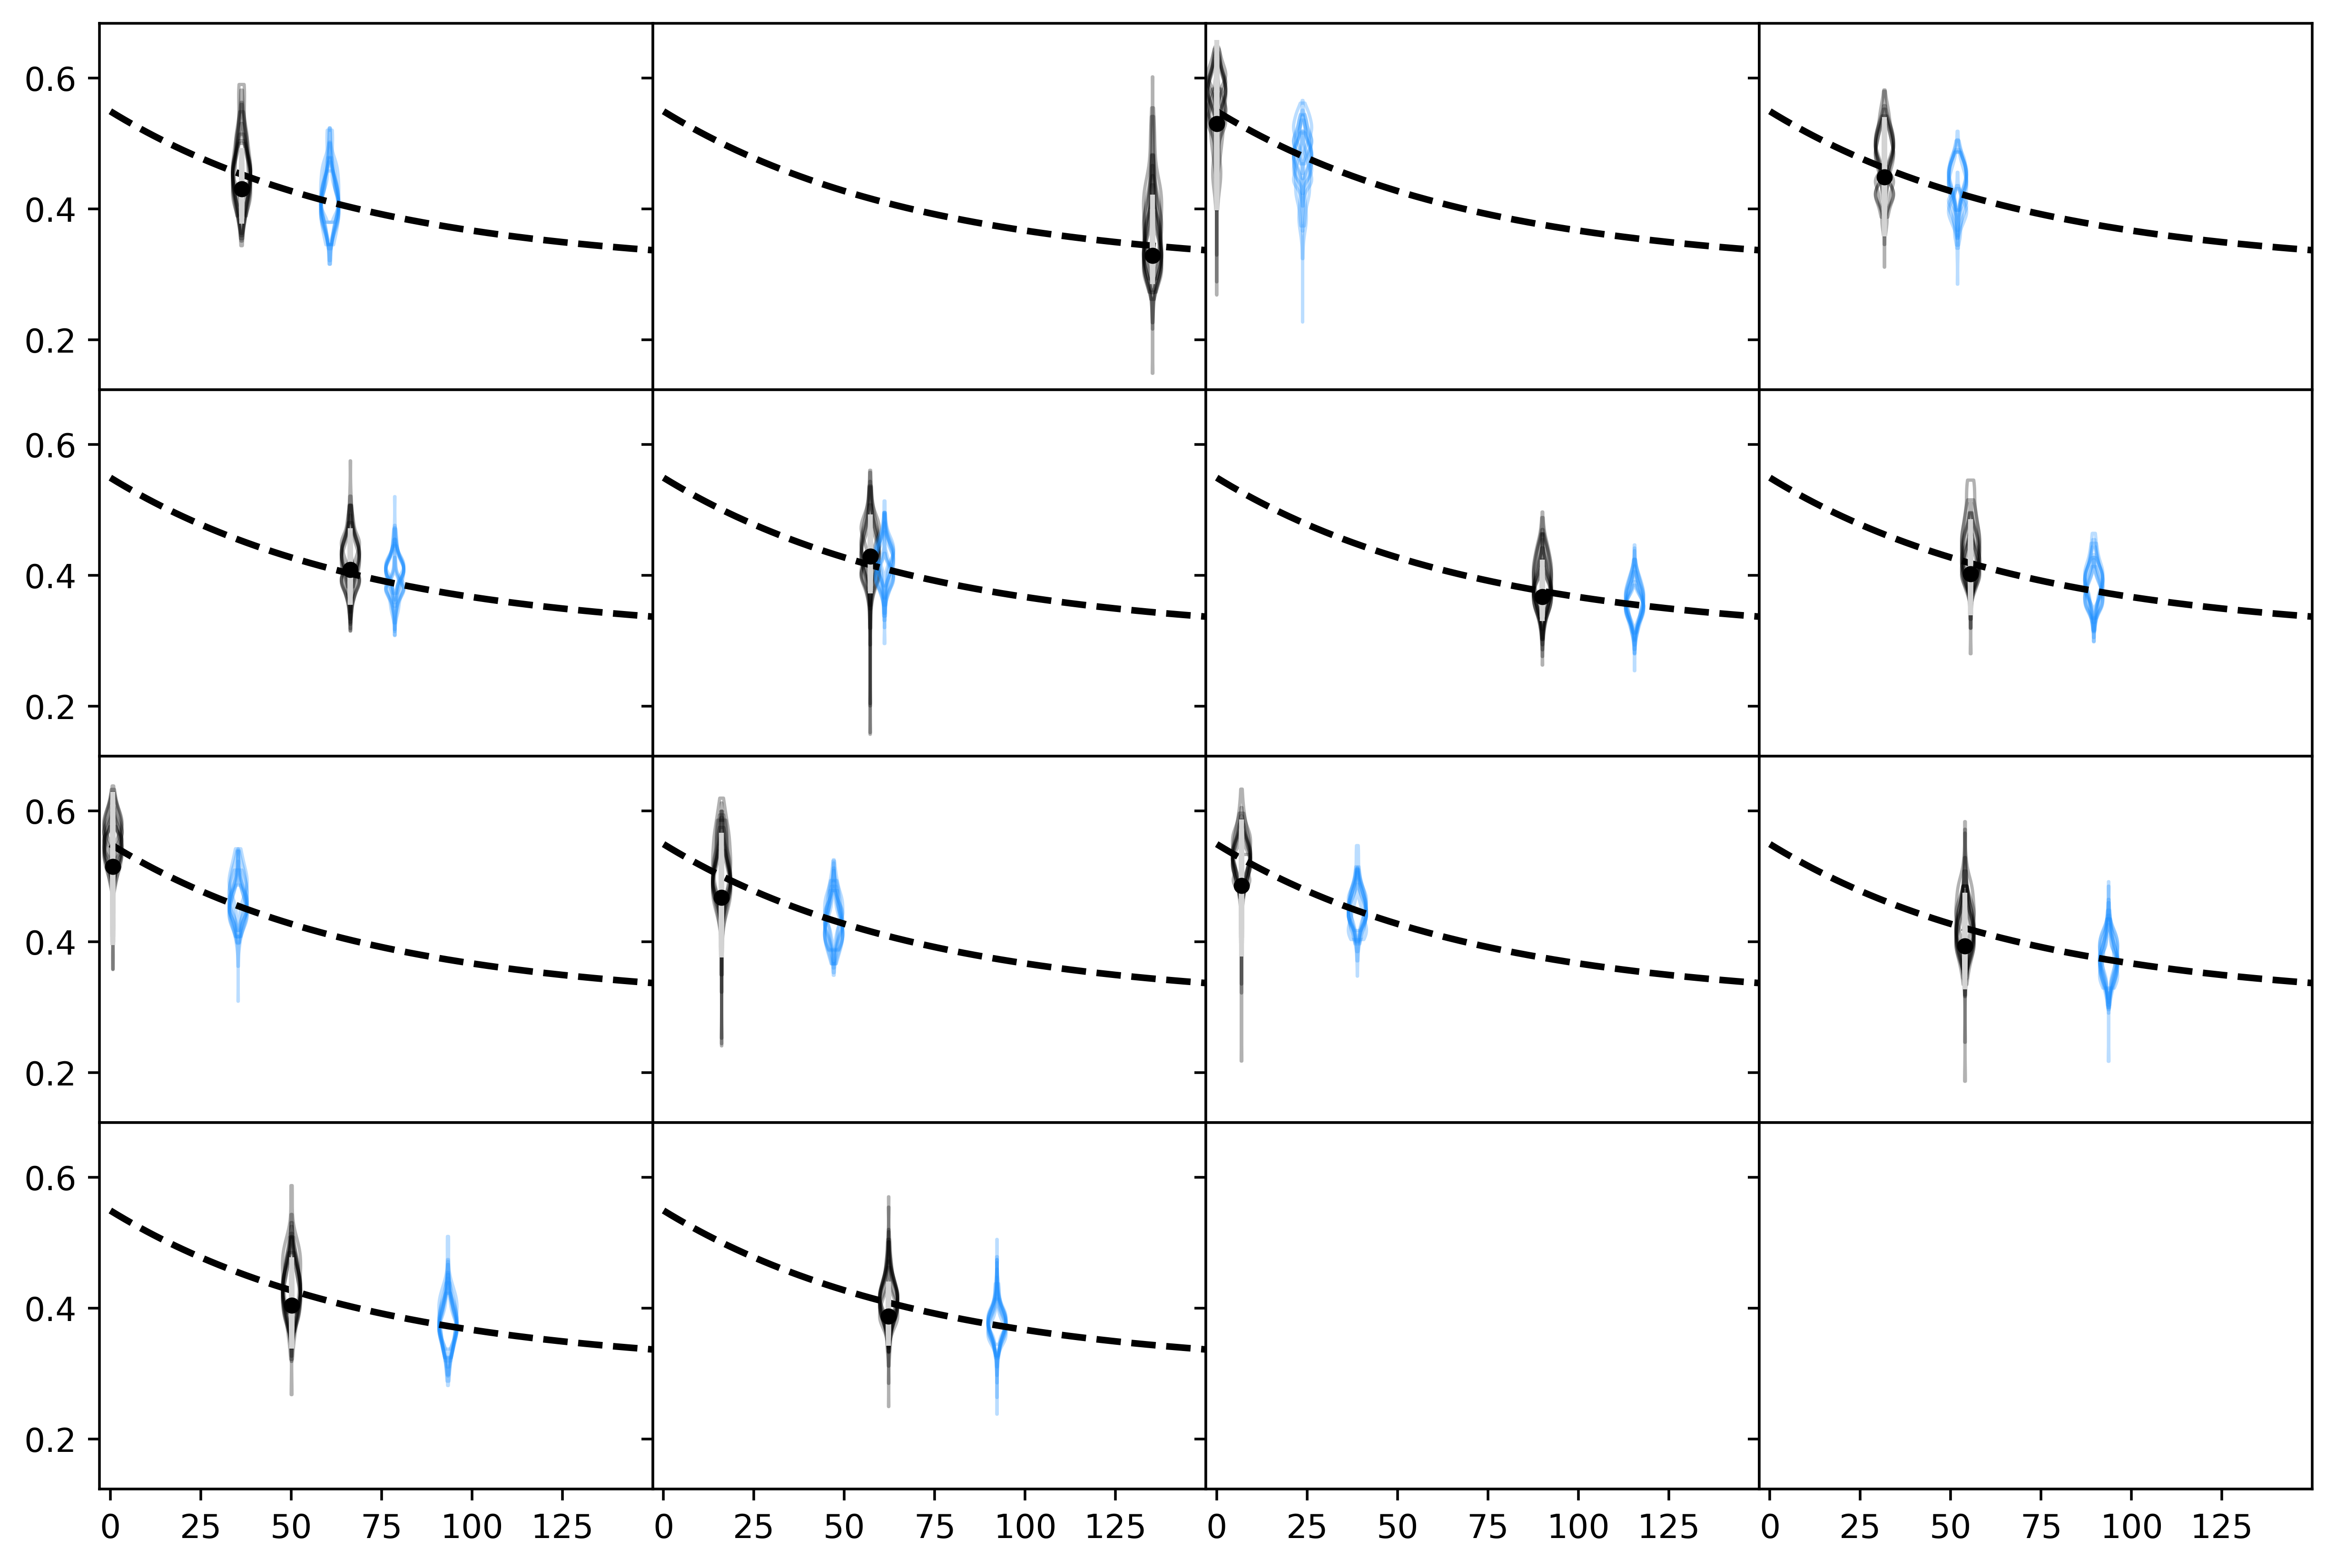

In [94]:

length_change_df = recom_df
#length_change_df = length_change_df.loc[length_change_df['timepoint']==8]

interp_x_from_y = lambda y: np.interp(y, model_df['y_model'][::-1], model_df['x_model'][::-1])
        
x_df = length_change_df.groupby(['construct', 'timepoint'], as_index=False)['Efret'].median().dropna()
x_df['x_intercept'] = x_df['Efret'].apply(interp_x_from_y)


uni_construct = length_change_df['construct'].unique().tolist()
uni_parameters = length_change_df['timepoint'].unique().tolist()


mpl.rcParams['figure.dpi'] = 500
fig, ax = plt.subplots(4, 4, figsize=(12,8), sharex=True, sharey=True)
ax  = ax.flatten()
colors = ['k', 'dodgerblue', 'firebrick']

basal_generator = length_change_df.groupby(['construct','timepoint', 'date', 'well'], observed=True)
medians = basal_generator['Efret'].median()
for index, df_container in enumerate(basal_generator):
    position = x_df.loc[(x_df['construct'] == df_container[0][0])  & (x_df['timepoint'] == df_container[0][1]), 'x_intercept'].iloc[0]
    color_index = uni_parameters.index(df_container[0][1])
    color = colors[color_index]
    
    if index == 0:
        #set current_construct to change positions
        current_construct = df_container[0][0]
        #initiate list for x tick label axis
        x_tick_list = [current_construct]
        
        # set up statistics to plot
        current_medians = medians[current_construct]
        experiment_median = current_medians.median()
        experiment_std = current_medians.std()
        row = 0
        plot_stats = False
        
    if current_construct != df_container[0][0]:
        
        current_construct = df_container[0][0]
        x_tick_list.append(current_construct)
        current_medians = medians[current_construct]
        experiment_median = current_medians.median()
        experiment_std = current_medians.std()
        
        
        
        plot_stats = False
        row += 1
        
    if not plot_stats:
        ax[row].errorbar(x=[position] * len(current_medians), 
                    y=current_medians, yerr=experiment_std, color='lightgray')
        ax[row].scatter(x=position, y=experiment_median, zorder=3, color='k', s=15)
        ax[row].set_xticks(np.arange(0, 150, 25))
        ax[row].plot(model_df['x_model'], model_df['y_model'], linestyle='--', color='k', lw=2, label='Fit (extrapolated)')
        ax[row].set_xlim([-3, 150])
        
        plot_stats = True
    basal_df = df_container[1]
    data = basal_df['Efret']
    violins = ax[row].violinplot(data, [position], widths=5, 
    showextrema=False, showmedians=False, showmeans=False)

    for pc in violins['bodies']:
        pc.set_facecolor('None')
        pc.set_edgecolor(color)
        pc.set_aplha=0.3

    #ax[row].text(position, experiment_median + 0.1, s=current_construct, ha='center')

plt.subplots_adjust(wspace=0, hspace=0)